In [18]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

In [6]:
RESULTS_DIR = Path("../../results/pjm/lstnet")

In [25]:
site = "NI"
versions = [f"version{v}" for v in (3, 4, 5, 6, 7, 8)]
n_folds = 10

version_maes = dict()
for version in versions:
    results_dir_path = RESULTS_DIR / site / version

    fold_maes = []
    for fold in range(n_folds):
        forecasts_path = results_dir_path / f"forecasts_{site}_fold_{fold}.pq"
        forecasts_df = pl.read_parquet(forecasts_path)
        errors = forecasts_df[f"{site}_MW"] - forecasts_df[f"{site}_MW_FORECAST"]
        mae = errors.abs().mean()
        fold_maes.append(mae)
    
    version_maes[version] = fold_maes

797.6907572428385
916.9167724609375
580.0459930419922
778.4486521402995
726.5291229248046
691.8305918375652


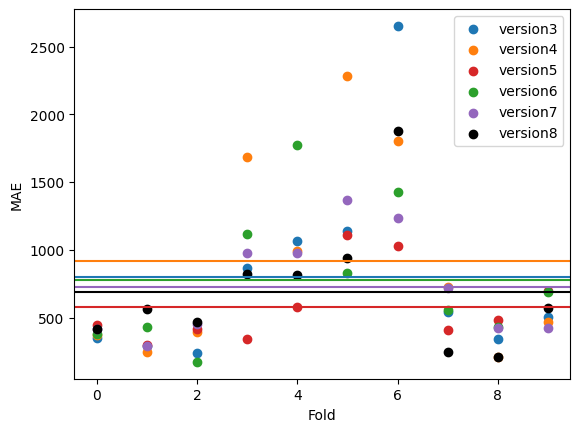

In [26]:
fig, ax = plt.subplots()
colors = ["tab:blue", "tab:orange", "tab:red", "tab:green", "tab:purple", "black"]
for v, version in enumerate(versions):
    ax.scatter(range(n_folds), version_maes[version], label=version, color=colors[v])
    ax.axhline(np.mean(version_maes[version]), color=colors[v])
    print(np.mean(version_maes[version]))

ax.set(xlabel="Fold", ylabel="MAE")
ax.legend()